# Decision Trees And Random Forests

Decision trees split data into smaller groups using simple rules. Random forests combine many decision trees to make a more stable model.

Steps:

1. Load the breast cancer dataset.
2. Split into train, validation, and test sets.
3. Tune decision tree depth using validation accuracy.
4. Train a simple random forest.
5. Retrain the final models on train + validation.
6. Test the final models once.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42

## Load Data

The target labels are:

- `0`: malignant
- `1`: benign

In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(dict(enumerate(cancer.target_names)))

X.head()

Samples: 569
Features: 30
{0: 'malignant', 1: 'benign'}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Train, Validation, Test Split

We use the training set to fit models, the validation set to choose the decision tree depth, and the test set once at the end.

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

pd.Series({
    "train": len(y_train),
    "validation": len(y_val),
    "test": len(y_test),
}).to_frame("n_samples")

,n_samples
train,398
validation,85
test,86


## Tune Decision Tree Depth

A shallow tree may be too simple. A very deep tree may overfit. We choose depth using validation accuracy.

We start at depth 2 so the tree is still visually useful for teaching.

In [4]:
depth_values = [2, 3, 4, 5, None]
dt_results = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    dt_results.append({
        "max_depth": "None" if depth is None else depth,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "validation_accuracy": accuracy_score(y_val, model.predict(X_val)),
    })

dt_results = pd.DataFrame(dt_results)
dt_results

,max_depth,train_accuracy,validation_accuracy
0,2,0.964824,0.941176
1,3,0.979899,0.941176
2,4,0.992462,0.929412
3,5,0.994975,0.929412
4,None,1.000000,0.929412


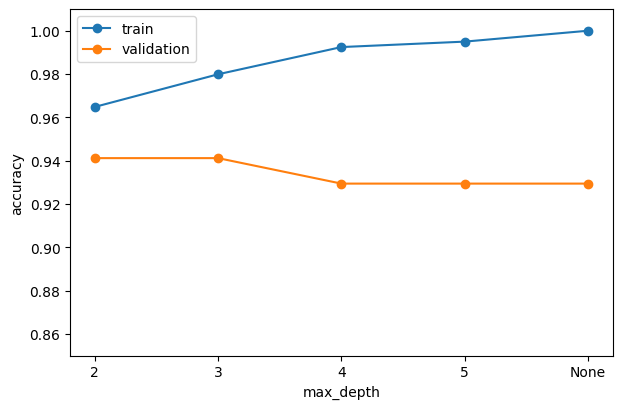

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(dt_results["max_depth"].astype(str), dt_results["train_accuracy"], marker="o", label="train")
ax.plot(dt_results["max_depth"].astype(str), dt_results["validation_accuracy"], marker="o", label="validation")
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_ylim(0.85, 1.01)
ax.legend()
plt.show()

In [6]:
best_dt_row = dt_results.sort_values(
    ["validation_accuracy", "train_accuracy"],
    ascending=False,
).iloc[0]

best_dt_depth = None if best_dt_row["max_depth"] == "None" else int(best_dt_row["max_depth"])

print("Best decision tree depth:", best_dt_depth)
print("Validation accuracy:", round(best_dt_row["validation_accuracy"], 3))

Best decision tree depth: 3
Validation accuracy: 0.941


## Visualize The Best Decision Tree

This is the selected tree fit on the training set.

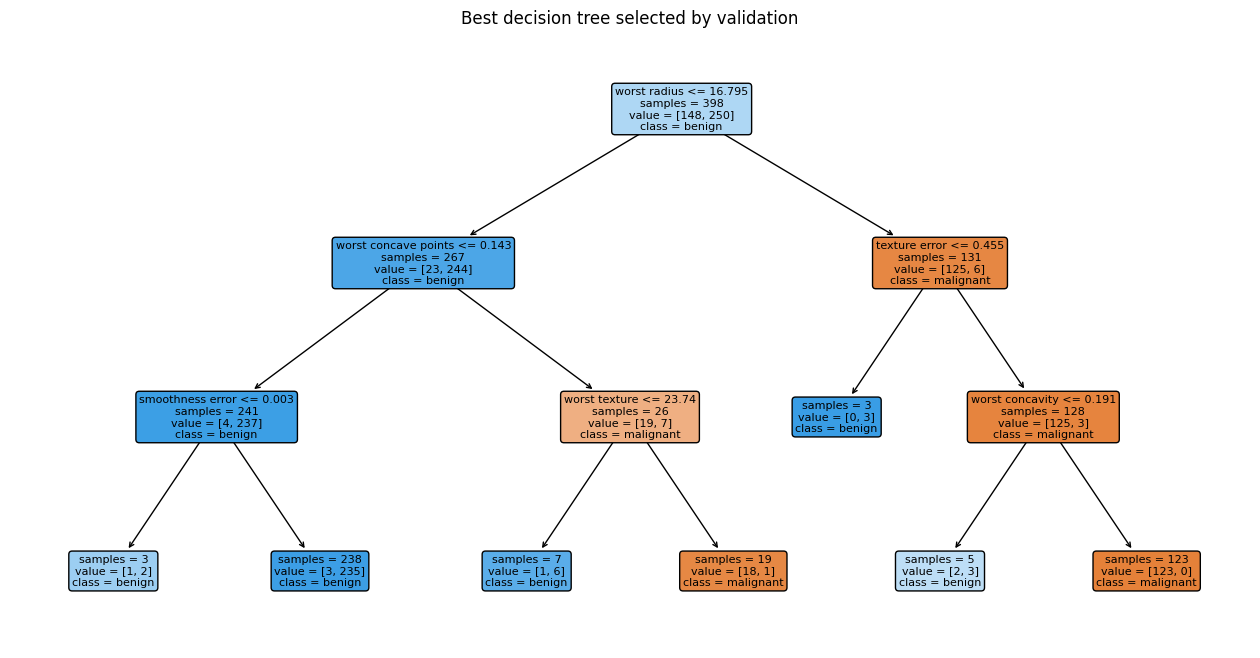

In [7]:
best_dt_for_plot = DecisionTreeClassifier(max_depth=best_dt_depth, random_state=RANDOM_STATE)
best_dt_for_plot.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(16, 8))

plot_tree(
    best_dt_for_plot,
    feature_names=cancer.feature_names,
    class_names=cancer.target_names,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
    ax=ax,
)

ax.set_title("Best decision tree selected by validation")
plt.show()

## Random Forest

For the random forest, we keep the model simple and use one fixed setting.

A random forest combines many decision trees, which usually makes it more stable than a single tree.

In [8]:
forest = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
forest.fit(X_train, y_train)

forest_train_accuracy = accuracy_score(y_train, forest.predict(X_train))
forest_validation_accuracy = accuracy_score(y_val, forest.predict(X_val))

print(f"Train accuracy: {forest_train_accuracy:.3f}")
print(f"Validation accuracy: {forest_validation_accuracy:.3f}")

Train accuracy: 1.000
Validation accuracy: 0.988


## Number Of Trees

Increasing `n_estimators` adds more trees to the forest. More trees usually makes the model more stable, but after a point the accuracy may stop improving.

This plot compares training and validation accuracy as the number of trees increases.

In [9]:
n_estimator_results = []

for n_estimators in [1, 5, 10, 25, 50, 100, 200, 500, 1000, 2000]:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    n_estimator_results.append({
        "n_estimators": n_estimators,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "validation_accuracy": accuracy_score(y_val, model.predict(X_val)),
    })

n_estimator_results = pd.DataFrame(n_estimator_results)
n_estimator_results

,n_estimators,train_accuracy,validation_accuracy
0,1,0.977387,0.941176
1,5,0.989950,0.964706
2,10,1.000000,0.964706
3,25,0.997487,0.976471
4,50,1.000000,0.964706
5,100,1.000000,0.988235
6,200,1.000000,0.988235
7,500,1.000000,0.988235
8,1000,1.000000,0.988235
9,2000,1.000000,0.988235


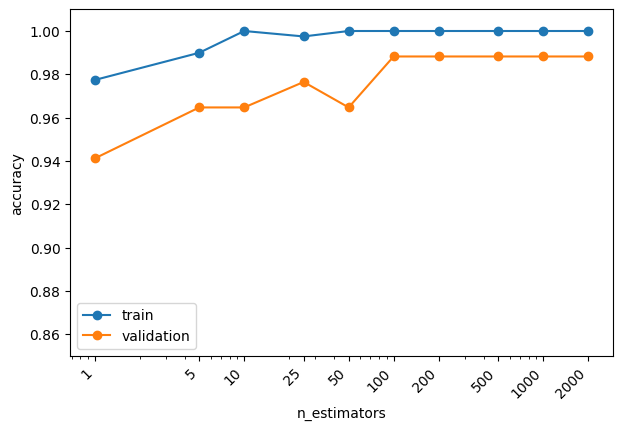

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(n_estimator_results["n_estimators"], n_estimator_results["train_accuracy"], marker="o", label="train")
ax.plot(n_estimator_results["n_estimators"], n_estimator_results["validation_accuracy"], marker="o", label="validation")
ax.set_xscale("log")
ax.set_xlabel("n_estimators")
ax.set_ylabel("accuracy")
ax.set_ylim(0.85, 1.01)
ax.set_xticks(n_estimator_results["n_estimators"])
ax.set_xticklabels(n_estimator_results["n_estimators"], rotation=45, ha="right")
ax.legend()
plt.show()

## Final Test

After selecting the decision tree depth, we retrain each model on train + validation. Then we test once on the held-out test set.

In [11]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

final_dt = DecisionTreeClassifier(max_depth=best_dt_depth, random_state=RANDOM_STATE)
final_dt.fit(X_train_val, y_train_val)

final_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_rf.fit(X_train_val, y_train_val)

final_results = pd.DataFrame({
    "model": ["Decision tree", "Random forest"],
    "test_accuracy": [
        accuracy_score(y_test, final_dt.predict(X_test)),
        accuracy_score(y_test, final_rf.predict(X_test)),
    ],
})

final_results

,model,test_accuracy
0,Decision tree,0.895349
1,Random forest,0.918605


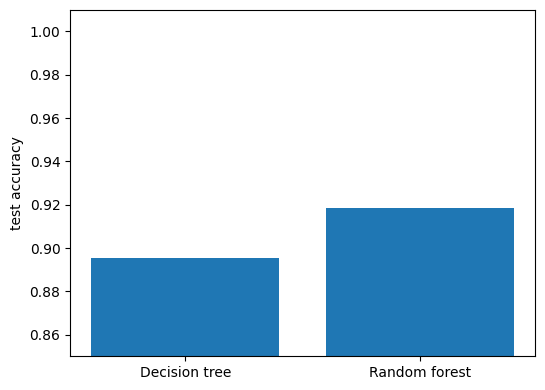

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))

ax.bar(final_results["model"], final_results["test_accuracy"])
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("test accuracy")
plt.show()

## Feature Importance

Random forests can estimate which features were most useful across the trees.

In [13]:
importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": final_rf.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

importance

,feature,importance
23,worst area,0.140153
22,worst perimeter,0.132352
27,worst concave points,0.112876
20,worst radius,0.098108
7,mean concave points,0.095017
0,mean radius,0.062523
2,mean perimeter,0.055459
3,mean area,0.047681
6,mean concavity,0.040002
26,worst concavity,0.031093


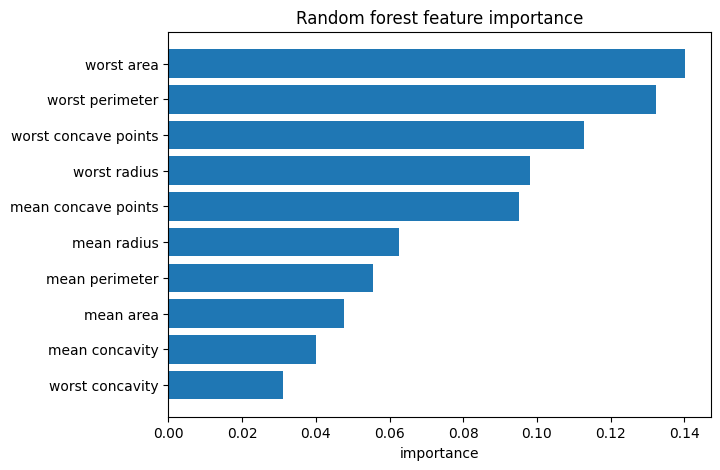

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.barh(importance["feature"][::-1], importance["importance"][::-1])
ax.set_xlabel("importance")
ax.set_title("Random forest feature importance")
plt.show()

## Confusion Matrices

The confusion matrices show where each final model made correct and incorrect predictions on the test set.

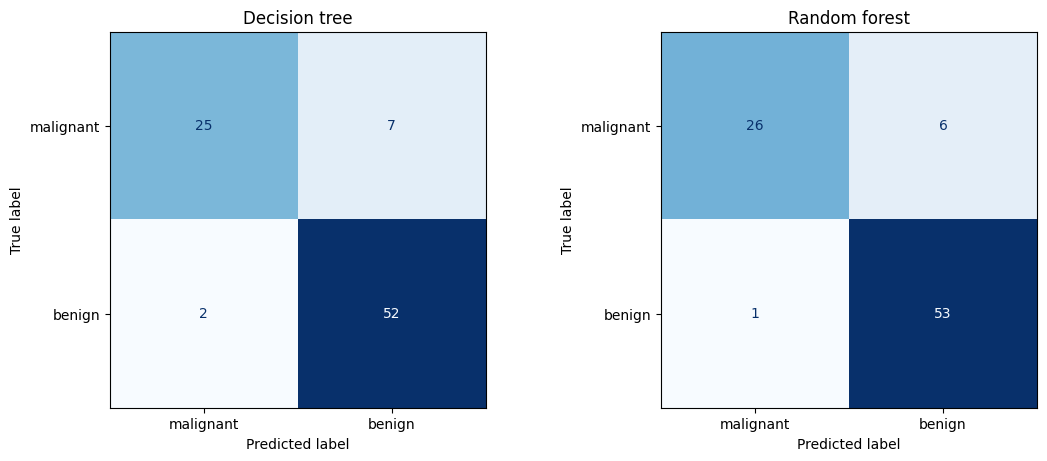

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ConfusionMatrixDisplay.from_estimator(
    final_dt,
    X_test,
    y_test,
    display_labels=cancer.target_names,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Decision tree")

ConfusionMatrixDisplay.from_estimator(
    final_rf,
    X_test,
    y_test,
    display_labels=cancer.target_names,
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Random forest")

plt.show()